In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
employee_df = pd.read_csv("employee_data 1.csv")
attrition_df = pd.read_csv("Attrition 1.csv")
performance_df = pd.read_csv("employee_performance_data 1.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
print("Employee Data Shape:", employee_df.shape)
print("Attrition Data Shape:", attrition_df.shape)
print("Performance Data Shape:", performance_df.shape)

Employee Data Shape: (1000, 12)
Attrition Data Shape: (144, 3)
Performance Data Shape: (1000, 6)


In [ ]:
# ============================================================
# STEP 3: INITIAL DATA INSPECTION
# ============================================================

datasets = {
    "Employee Data": employee_df,
    "Attrition Data": attrition_df,
    "Performance Data": performance_df
}

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())


Employee Data

Columns:
['Employee_ID', 'Age', 'first_name', 'last_name', 'gender', 'Gender', 'Department', 'Job_Role', 'Education_Level', 'Marital_Status', 'Job_Tenure', 'Distance_From_Home']

Data Types:
Employee_ID            int64
Age                    int64
first_name            object
last_name             object
gender                object
Gender                object
Department            object
Job_Role              object
Education_Level       object
Marital_Status        object
Job_Tenure             int64
Distance_From_Home     int64
dtype: object

First 5 Rows:


,Employee_ID,Age,first_name,last_name,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home
0,1,22,Konstantin,Shutler,Male,Other,HR,Developer,PhD,Married,1,8
1,2,38,Thorvald,Skoggins,Male,Other,IT,Marketing Lead,Master's,Married,18,32
2,3,35,Gracia,Teggin,Genderqueer,Male,Sales,Senior Developer,Bachelor's,Divorced,4,42
3,4,37,Kerwinn,Romme,Male,Male,Marketing,Senior Developer,Bachelor's,Divorced,5,43
4,5,26,Randene,Millier,Female,Female,Operations,Manager,Master's,Single,10,33



Attrition Data

Columns:
['employee_ID', 'attrition', 'Exit_Interview_Score']

Data Types:
employee_ID             int64
attrition                bool
Exit_Interview_Score    int64
dtype: object

First 5 Rows:


,employee_ID,attrition,Exit_Interview_Score
0,474,True,2
1,97,True,4
2,729,False,1
3,278,False,2
4,470,False,4



Performance Data

Columns:
['Employee_ID', 'Performance_Rating', 'Last_Promotion_Year', 'Training_Hours', 'Work_Life_Balance', 'Job_Satisfaction']

Data Types:
Employee_ID            int64
Performance_Rating     int64
Last_Promotion_Year    int64
Training_Hours         int64
Work_Life_Balance      int64
Job_Satisfaction       int64
dtype: object

First 5 Rows:


,Employee_ID,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction
0,1,2,2019,28,3,1
1,2,4,2022,174,3,2
2,3,1,2022,119,5,4
3,4,4,2015,82,4,1
4,5,3,2014,46,2,4


In [ ]:
# ============================================================
# STEP 4: DATA QUALITY PROFILING
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate rows
    print("\nDuplicate Rows:", df.duplicated().sum())

    # Number of unique values in each column
    print("\nUnique Values:")
    print(df.nunique())


Employee Data

Missing Values:
Employee_ID           0
Age                   0
first_name            0
last_name             0
gender                0
Gender                0
Department            0
Job_Role              0
Education_Level       0
Marital_Status        0
Job_Tenure            0
Distance_From_Home    0
dtype: int64

Duplicate Rows: 0

Unique Values:
Employee_ID           1000
Age                     39
first_name             939
last_name              980
gender                   8
Gender                   3
Department               6
Job_Role                 6
Education_Level          3
Marital_Status           3
Job_Tenure              20
Distance_From_Home      50
dtype: int64

Attrition Data

Missing Values:
employee_ID             0
attrition               0
Exit_Interview_Score    0
dtype: int64

Duplicate Rows: 2

Unique Values:
employee_ID             127
attrition                 2
Exit_Interview_Score      5
dtype: int64

Performance Data

Missing Values:
Empl

In [ ]:
# ============================================================
# STEP 5: INVESTIGATE GENDER COLUMNS
# ============================================================

print("Values in 'gender':")
print(employee_df["gender"].value_counts(dropna=False))

print("\n" + "=" * 50)

print("Values in 'Gender':")
print(employee_df["Gender"].value_counts(dropna=False))

print("\n" + "=" * 50)

# Compare the two columns
gender_comparison = pd.crosstab(
    employee_df["gender"],
    employee_df["Gender"],
    margins=True
)

print("Comparison between 'gender' and 'Gender':")
display(gender_comparison)

Values in 'gender':
gender
Female         453
Male           442
Agender         21
Bigender        21
Non-binary      19
Genderqueer     16
Genderfluid     16
Polygender      12
Name: count, dtype: int64

Values in 'Gender':
Gender
Other     343
Female    336
Male      321
Name: count, dtype: int64

Comparison between 'gender' and 'Gender':


Gender,Female,Male,Other,All
gender,,,,
Agender,6,9,6,21
Bigender,9,8,4,21
Female,155,145,153,453
Genderfluid,9,3,4,16
Genderqueer,5,6,5,16
Male,141,139,162,442
Non-binary,6,7,6,19
Polygender,5,4,3,12
All,336,321,343,1000


In [ ]:
# ============================================================
# STEP 6: INVESTIGATE DUPLICATES IN ATTRITION DATA
# ============================================================

# Find all duplicate rows
attrition_duplicates = attrition_df[
    attrition_df.duplicated(keep=False)
].sort_values("employee_ID")

print("Duplicate records in Attrition Data:")
display(attrition_duplicates)

print("\nNumber of duplicate rows:", len(attrition_duplicates))

print("\nEmployee IDs involved in duplicates:")
print(attrition_duplicates["employee_ID"].unique())

Duplicate records in Attrition Data:


,employee_ID,attrition,Exit_Interview_Score
58,561,False,2
119,561,False,2
14,742,False,3
82,742,False,3



Number of duplicate rows: 4

Employee IDs involved in duplicates:
[561 742]


In [ ]:
# ============================================================
# STEP 7: VALIDATE ATTRITION EMPLOYEE IDs
# ============================================================

# Count records for each Employee ID
attrition_id_counts = (
    attrition_df
    .groupby("employee_ID")
    .size()
    .reset_index(name="Record_Count")
    .sort_values("Record_Count", ascending=False)
)

print("Employee IDs with more than one record:")
display(
    attrition_id_counts[
        attrition_id_counts["Record_Count"] > 1
    ]
)

print("\n" + "=" * 60)

# Check whether any Employee ID has conflicting attrition values
attrition_conflicts = (
    attrition_df
    .groupby("employee_ID")["attrition"]
    .nunique()
)

conflicting_ids = attrition_conflicts[
    attrition_conflicts > 1
]

print("Employee IDs with conflicting Attrition values:")
print(conflicting_ids)

print("\nNumber of conflicting Employee IDs:", len(conflicting_ids))

Employee IDs with more than one record:


,employee_ID,Record_Count
14,129,2
11,97,2
27,253,2
28,262,2
29,272,2
19,216,2
18,213,2
43,357,2
118,959,2
115,929,2



Employee IDs with conflicting Attrition values:
employee_ID
213    2
253    2
357    2
556    2
897    2
929    2
Name: attrition, dtype: int64

Number of conflicting Employee IDs: 6


In [ ]:
# ============================================================
# STEP 8: INVESTIGATE REPEATED EMPLOYEE IDs
# ============================================================

repeated_ids = (
    attrition_df["employee_ID"]
    .value_counts()
)

repeated_ids = repeated_ids[repeated_ids > 1].index

repeated_attrition = (
    attrition_df[
        attrition_df["employee_ID"].isin(repeated_ids)
    ]
    .sort_values("employee_ID")
)

print("All repeated Employee IDs in Attrition Data:")
display(repeated_attrition)

All repeated Employee IDs in Attrition Data:


,employee_ID,attrition,Exit_Interview_Score
1,97,True,4
100,97,True,2
107,129,False,4
127,129,False,5
121,213,True,4
139,213,False,2
93,216,True,1
76,216,True,2
45,253,False,4
13,253,True,5


In [ ]:
# ============================================================
# STEP 9: VALIDATE REPEATED ATTRITION IDs AGAINST EMPLOYEE DATA
# ============================================================

repeated_ids = attrition_df["employee_ID"].value_counts()
repeated_ids = repeated_ids[repeated_ids > 1].index

# Get corresponding employee records
repeated_employee_data = employee_df[
    employee_df["Employee_ID"].isin(repeated_ids)
].copy()

# Select useful columns for inspection
repeated_employee_data = repeated_employee_data[
    [
        "Employee_ID",
        "Age",
        "gender",
        "Gender",
        "Department",
        "Job_Role",
        "Education_Level",
        "Marital_Status",
        "Job_Tenure",
        "Distance_From_Home"
    ]
].sort_values("Employee_ID")

print("Employee information for repeated Attrition IDs:")
display(repeated_employee_data)

Employee information for repeated Attrition IDs:


,Employee_ID,Age,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home
96,97,46,Male,Male,Sales,Marketing Lead,Master's,Divorced,8,39
128,129,27,Male,Other,Finance,Manager,PhD,Married,14,26
212,213,50,Male,Other,HR,HR Specialist,Master's,Married,13,44
215,216,48,Male,Other,IT,Data Analyst,Master's,Married,11,39
252,253,23,Agender,Other,Operations,Data Analyst,PhD,Single,3,28
261,262,57,Female,Other,HR,Manager,Master's,Single,2,50
271,272,32,Female,Other,Marketing,Manager,Bachelor's,Divorced,5,37
356,357,57,Female,Male,Operations,Senior Developer,Bachelor's,Single,11,4
555,556,39,Non-binary,Male,Sales,Data Analyst,PhD,Single,17,12
560,561,29,Male,Female,Operations,Data Analyst,Bachelor's,Married,6,20


In [ ]:
# ============================================================
# STEP 10: CLASSIFY ATTRITION DUPLICATES
# ============================================================

# Count unique attrition values for each Employee ID
attrition_status_count = (
    attrition_df
    .groupby("employee_ID")["attrition"]
    .nunique()
    .reset_index(name="Unique_Attrition_Values")
)

# Identify repeated Employee IDs
repeated_ids = (
    attrition_df["employee_ID"]
    .value_counts()
    .reset_index()
)

repeated_ids.columns = ["employee_ID", "Record_Count"]

repeated_ids = repeated_ids[
    repeated_ids["Record_Count"] > 1
]

# Combine the information
duplicate_report = repeated_ids.merge(
    attrition_status_count,
    on="employee_ID",
    how="left"
)

# Classify
duplicate_report["Duplicate_Type"] = np.where(
    duplicate_report["Unique_Attrition_Values"] == 1,
    "Non-Conflicting Duplicate",
    "Conflicting Duplicate"
)

print("Attrition Duplicate Classification:")
display(duplicate_report)

print("\n" + "=" * 60)

print("Summary:")
print(
    duplicate_report["Duplicate_Type"]
    .value_counts()
)

Attrition Duplicate Classification:


,employee_ID,Record_Count,Unique_Attrition_Values,Duplicate_Type
0,97,2,1,Non-Conflicting Duplicate
1,897,2,2,Conflicting Duplicate
2,790,2,1,Non-Conflicting Duplicate
3,742,2,1,Non-Conflicting Duplicate
4,253,2,2,Conflicting Duplicate
5,929,2,2,Conflicting Duplicate
6,684,2,1,Non-Conflicting Duplicate
7,561,2,1,Non-Conflicting Duplicate
8,262,2,1,Non-Conflicting Duplicate
9,640,2,1,Non-Conflicting Duplicate



Summary:
Duplicate_Type
Non-Conflicting Duplicate    11
Conflicting Duplicate         6
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 11: CLEAN ATTRITION DATA
# ============================================================

# ------------------------------------------------------------
# 1. Identify conflicting Employee IDs
# ------------------------------------------------------------

conflicting_ids = (
    attrition_df
    .groupby("employee_ID")["attrition"]
    .nunique()
)

conflicting_ids = conflicting_ids[
    conflicting_ids > 1
].index.tolist()

print("Conflicting Employee IDs:")
print(conflicting_ids)


# ------------------------------------------------------------
# 2. Create a separate conflict report
# ------------------------------------------------------------

attrition_conflict_df = attrition_df[
    attrition_df["employee_ID"].isin(conflicting_ids)
].copy()

print("\nConflicting records kept separately for review:")
display(
    attrition_conflict_df.sort_values("employee_ID")
)


# ------------------------------------------------------------
# 3. Remove conflicting records from the analytical dataset
# ------------------------------------------------------------

attrition_clean = attrition_df[
    ~attrition_df["employee_ID"].isin(conflicting_ids)
].copy()


# ------------------------------------------------------------
# 4. Remove exact/non-conflicting duplicate records
# ------------------------------------------------------------

attrition_clean = attrition_clean.drop_duplicates(
    subset=["employee_ID"],
    keep="first"
).reset_index(drop=True)


# ------------------------------------------------------------
# 5. Check the cleaned dataset
# ------------------------------------------------------------

print("\nOriginal Attrition Records:", len(attrition_df))
print("Conflicting Records Removed:", len(attrition_conflict_df))
print("Clean Attrition Records:", len(attrition_clean))

print("\nDuplicate Employee IDs after cleaning:")
print(
    attrition_clean["employee_ID"]
    .duplicated()
    .sum()
)

print("\nClean Attrition Data:")
display(attrition_clean.head())

Conflicting Employee IDs:
[213, 253, 357, 556, 897, 929]

Conflicting records kept separately for review:


,employee_ID,attrition,Exit_Interview_Score
121,213,True,4
139,213,False,2
13,253,True,5
45,253,False,4
66,357,True,5
67,357,False,2
68,556,True,4
36,556,False,5
28,897,True,2
6,897,False,4



Original Attrition Records: 144
Conflicting Records Removed: 12
Clean Attrition Records: 121

Duplicate Employee IDs after cleaning:
0

Clean Attrition Data:


,employee_ID,attrition,Exit_Interview_Score
0,474,True,2
1,97,True,4
2,729,False,1
3,278,False,2
4,470,False,4


In [ ]:
# ============================================================
# STEP 12: EMPLOYEE_ID RELATIONSHIP VALIDATION
# ============================================================

print("=" * 70)
print("EMPLOYEE ID RELATIONSHIP VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Employee Data
# ------------------------------------------------------------

employee_ids = set(employee_df["Employee_ID"])

# ------------------------------------------------------------
# 2. Performance Data
# ------------------------------------------------------------

performance_ids = set(performance_df["Employee_ID"])

# ------------------------------------------------------------
# 3. Clean Attrition Data
# ------------------------------------------------------------

attrition_ids = set(attrition_clean["employee_ID"])


# ------------------------------------------------------------
# Employee Data ↔ Performance Data
# ------------------------------------------------------------

employee_not_in_performance = employee_ids - performance_ids
performance_not_in_employee = performance_ids - employee_ids

print("\nEmployee Data → Performance Data")
print("Employees missing in Performance Data:",
      len(employee_not_in_performance))

print("Performance employees missing in Employee Data:",
      len(performance_not_in_employee))


# ------------------------------------------------------------
# Employee Data ↔ Attrition Data
# ------------------------------------------------------------

employee_not_in_attrition = employee_ids - attrition_ids
attrition_not_in_employee = attrition_ids - employee_ids

print("\nEmployee Data → Clean Attrition Data")
print("Employees without Attrition records:",
      len(employee_not_in_attrition))

print("Attrition IDs missing in Employee Data:",
      len(attrition_not_in_employee))


# ------------------------------------------------------------
# Performance Data ↔ Attrition Data
# ------------------------------------------------------------

performance_not_in_attrition = performance_ids - attrition_ids
attrition_not_in_performance = attrition_ids - performance_ids

print("\nPerformance Data → Clean Attrition Data")
print("Performance employees without Attrition records:",
      len(performance_not_in_attrition))

print("Attrition employees without Performance records:",
      len(attrition_not_in_performance))


# ------------------------------------------------------------
# Common employees across all 3 datasets
# ------------------------------------------------------------

common_ids = (
    employee_ids
    & performance_ids
    & attrition_ids
)

print("\n" + "=" * 70)
print("COMMON EMPLOYEES ACROSS ALL THREE DATASETS:", len(common_ids))
print("=" * 70)

EMPLOYEE ID RELATIONSHIP VALIDATION

Employee Data → Performance Data
Employees missing in Performance Data: 0
Performance employees missing in Employee Data: 0

Employee Data → Clean Attrition Data
Employees without Attrition records: 879
Attrition IDs missing in Employee Data: 0

Performance Data → Clean Attrition Data
Performance employees without Attrition records: 879
Attrition employees without Performance records: 0

COMMON EMPLOYEES ACROSS ALL THREE DATASETS: 121


In [ ]:
# ============================================================
# STEP 13: VALUE RANGE & CATEGORY VALIDATION
# ============================================================

print("=" * 70)
print("VALUE RANGE & CATEGORY VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# EMPLOYEE DATA
# ------------------------------------------------------------

print("\n--- EMPLOYEE DATA ---")

print("\nAge Range:")
print("Min:", employee_df["Age"].min())
print("Max:", employee_df["Age"].max())

print("\nJob Tenure Range:")
print("Min:", employee_df["Job_Tenure"].min())
print("Max:", employee_df["Job_Tenure"].max())

print("\nDistance From Home Range:")
print("Min:", employee_df["Distance_From_Home"].min())
print("Max:", employee_df["Distance_From_Home"].max())

print("\nDepartments:")
print(sorted(employee_df["Department"].unique()))

print("\nJob Roles:")
print(sorted(employee_df["Job_Role"].unique()))

print("\nEducation Levels:")
print(sorted(employee_df["Education_Level"].unique()))

print("\nMarital Status:")
print(sorted(employee_df["Marital_Status"].unique()))


# ------------------------------------------------------------
# PERFORMANCE DATA
# ------------------------------------------------------------

print("\n--- PERFORMANCE DATA ---")

print("\nPerformance Rating Range:")
print("Min:", performance_df["Performance_Rating"].min())
print("Max:", performance_df["Performance_Rating"].max())

print("\nLast Promotion Year Range:")
print("Min:", performance_df["Last_Promotion_Year"].min())
print("Max:", performance_df["Last_Promotion_Year"].max())

print("\nTraining Hours Range:")
print("Min:", performance_df["Training_Hours"].min())
print("Max:", performance_df["Training_Hours"].max())

print("\nWork-Life Balance Range:")
print("Min:", performance_df["Work_Life_Balance"].min())
print("Max:", performance_df["Work_Life_Balance"].max())

print("\nJob Satisfaction Range:")
print("Min:", performance_df["Job_Satisfaction"].min())
print("Max:", performance_df["Job_Satisfaction"].max())


# ------------------------------------------------------------
# ATTRITION DATA
# ------------------------------------------------------------

print("\n--- ATTRITION DATA ---")

print("\nAttrition Values:")
print(attrition_clean["attrition"].value_counts())

print("\nExit Interview Score Range:")
print("Min:", attrition_clean["Exit_Interview_Score"].min())
print("Max:", attrition_clean["Exit_Interview_Score"].max())

print("\n" + "=" * 70)

VALUE RANGE & CATEGORY VALIDATION

--- EMPLOYEE DATA ---

Age Range:
Min: 22
Max: 60

Job Tenure Range:
Min: 1
Max: 20

Distance From Home Range:
Min: 1
Max: 50

Departments:
['Finance', 'HR', 'IT', 'Marketing', 'Operations', 'Sales']

Job Roles:
['Data Analyst', 'Developer', 'HR Specialist', 'Manager', 'Marketing Lead', 'Senior Developer']

Education Levels:
["Bachelor's", "Master's", 'PhD']

Marital Status:
['Divorced', 'Married', 'Single']

--- PERFORMANCE DATA ---

Performance Rating Range:
Min: 1
Max: 5

Last Promotion Year Range:
Min: 2010
Max: 2024

Training Hours Range:
Min: 10
Max: 200

Work-Life Balance Range:
Min: 1
Max: 5

Job Satisfaction Range:
Min: 1
Max: 5

--- ATTRITION DATA ---

Attrition Values:
attrition
False    63
True     58
Name: count, dtype: int64

Exit Interview Score Range:
Min: 1
Max: 5



In [ ]:
# ============================================================
# STEP 14: CREATE MASTER EMPLOYEE DATASET
# ============================================================

# ------------------------------------------------------------
# 1. Standardize Attrition column name
# ------------------------------------------------------------

attrition_master = attrition_clean.rename(
    columns={"employee_ID": "Employee_ID"}
).copy()


# ------------------------------------------------------------
# 2. Merge Employee Data with Performance Data
# ------------------------------------------------------------

master_df = employee_df.merge(
    performance_df,
    on="Employee_ID",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 3. Merge Attrition Data
# ------------------------------------------------------------

master_df = master_df.merge(
    attrition_master,
    on="Employee_ID",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. Display structure
# ------------------------------------------------------------

print("=" * 70)
print("MASTER EMPLOYEE DATASET")
print("=" * 70)

print("\nShape:", master_df.shape)

print("\nColumns:")
print(master_df.columns.tolist())

print("\nFirst 5 rows:")
display(master_df.head())


# ------------------------------------------------------------
# 5. Check Employee_ID uniqueness
# ------------------------------------------------------------

print("\nDuplicate Employee_IDs:")
print(master_df["Employee_ID"].duplicated().sum())


# ------------------------------------------------------------
# 6. Check Attrition coverage
# ------------------------------------------------------------

print("\nAttrition records available:")
print(master_df["attrition"].notna().sum())

print("Employees without Attrition records:")
print(master_df["attrition"].isna().sum())


# ------------------------------------------------------------
# 7. Check merge integrity
# ------------------------------------------------------------

print("\nMaster Dataset Summary:")
print("Total Employees:", master_df["Employee_ID"].nunique())
print("Performance Records:", master_df["Performance_Rating"].notna().sum())
print("Attrition Records:", master_df["attrition"].notna().sum())

print("\n" + "=" * 70)

MASTER EMPLOYEE DATASET

Shape: (1000, 19)

Columns:
['Employee_ID', 'Age', 'first_name', 'last_name', 'gender', 'Gender', 'Department', 'Job_Role', 'Education_Level', 'Marital_Status', 'Job_Tenure', 'Distance_From_Home', 'Performance_Rating', 'Last_Promotion_Year', 'Training_Hours', 'Work_Life_Balance', 'Job_Satisfaction', 'attrition', 'Exit_Interview_Score']

First 5 rows:


,Employee_ID,Age,first_name,last_name,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction,attrition,Exit_Interview_Score
0,1,22,Konstantin,Shutler,Male,Other,HR,Developer,PhD,Married,1,8,2,2019,28,3,1,NaN,NaN
1,2,38,Thorvald,Skoggins,Male,Other,IT,Marketing Lead,Master's,Married,18,32,4,2022,174,3,2,False,3.0
2,3,35,Gracia,Teggin,Genderqueer,Male,Sales,Senior Developer,Bachelor's,Divorced,4,42,1,2022,119,5,4,NaN,NaN
3,4,37,Kerwinn,Romme,Male,Male,Marketing,Senior Developer,Bachelor's,Divorced,5,43,4,2015,82,4,1,NaN,NaN
4,5,26,Randene,Millier,Female,Female,Operations,Manager,Master's,Single,10,33,3,2014,46,2,4,NaN,NaN



Duplicate Employee_IDs:
0

Attrition records available:
121
Employees without Attrition records:
879

Master Dataset Summary:
Total Employees: 1000
Performance Records: 1000
Attrition Records: 121



In [ ]:
# ============================================================
# STEP 15: MASTER DATASET MISSING VALUE ANALYSIS
# ============================================================

print("=" * 70)
print("MASTER DATASET - MISSING VALUE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Missing values
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "Missing_Count": master_df.isnull().sum(),
    "Missing_Percentage": (
        master_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

print("\nColumns containing missing values:")
display(missing_summary)


# ------------------------------------------------------------
# 2. Check whether missing values are only from Attrition
# ------------------------------------------------------------

print("\nMissing values in Performance columns:")

performance_columns = [
    "Performance_Rating",
    "Last_Promotion_Year",
    "Training_Hours",
    "Work_Life_Balance",
    "Job_Satisfaction"
]

display(
    master_df[performance_columns]
    .isnull()
    .sum()
)


# ------------------------------------------------------------
# 3. Check missing values in Employee columns
# ------------------------------------------------------------

print("\nMissing values in Employee columns:")

employee_columns = [
    "Employee_ID",
    "Age",
    "first_name",
    "last_name",
    "gender",
    "Gender",
    "Department",
    "Job_Role",
    "Education_Level",
    "Marital_Status",
    "Job_Tenure",
    "Distance_From_Home"
]

display(
    master_df[employee_columns]
    .isnull()
    .sum()
)


# ------------------------------------------------------------
# 4. Confirm Attrition missing count
# ------------------------------------------------------------

print("\nAttrition missing values:")
print(master_df["attrition"].isnull().sum())

print("Exit Interview Score missing values:")
print(master_df["Exit_Interview_Score"].isnull().sum())

print("\n" + "=" * 70)

MASTER DATASET - MISSING VALUE ANALYSIS

Columns containing missing values:


,Missing_Count,Missing_Percentage
attrition,879,87.9
Exit_Interview_Score,879,87.9



Missing values in Performance columns:


,0
Performance_Rating,0
Last_Promotion_Year,0
Training_Hours,0
Work_Life_Balance,0
Job_Satisfaction,0



Missing values in Employee columns:


,0
Employee_ID,0
Age,0
first_name,0
last_name,0
gender,0
Gender,0
Department,0
Job_Role,0
Education_Level,0
Marital_Status,0



Attrition missing values:
879
Exit Interview Score missing values:
879



In [ ]:
# ============================================================
# STEP 16: CREATE ATTRITION ANALYSIS FLAGS
# ============================================================

# ------------------------------------------------------------
# 1. Attrition Status
# ------------------------------------------------------------

master_df["Attrition_Status"] = np.where(
    master_df["attrition"].isna(),
    "Unknown",
    np.where(
        master_df["attrition"] == True,
        "Attrited",
        "Not Attrited"
    )
)


# ------------------------------------------------------------
# 2. Attrition Availability Flag
# ------------------------------------------------------------

master_df["Attrition_Available"] = np.where(
    master_df["attrition"].notna(),
    1,
    0
)


# ------------------------------------------------------------
# 3. Check distribution
# ------------------------------------------------------------

print("=" * 70)
print("ATTRITION STATUS DISTRIBUTION")
print("=" * 70)

print("\nAttrition Status:")
print(
    master_df["Attrition_Status"]
    .value_counts()
)


# ------------------------------------------------------------
# 4. Attrition availability
# ------------------------------------------------------------

print("\nAttrition Availability:")
print(
    master_df["Attrition_Available"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 5. Cross-check against original attrition values
# ------------------------------------------------------------

print("\nKnown Attrition Records:")

display(
    master_df.loc[
        master_df["Attrition_Available"] == 1,
        [
            "Employee_ID",
            "attrition",
            "Attrition_Status",
            "Exit_Interview_Score"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 6. Check new columns
# ------------------------------------------------------------

print("\nNew columns added:")
print([
    "Attrition_Status",
    "Attrition_Available"
])

print("\nMaster Dataset Shape:")
print(master_df.shape)

print("\n" + "=" * 70)

ATTRITION STATUS DISTRIBUTION

Attrition Status:
Attrition_Status
Unknown         879
Not Attrited     63
Attrited         58
Name: count, dtype: int64

Attrition Availability:
Attrition_Available
0    879
1    121
Name: count, dtype: int64

Known Attrition Records:


,Employee_ID,attrition,Attrition_Status,Exit_Interview_Score
1,2,False,Not Attrited,3.0
10,11,False,Not Attrited,2.0
12,13,False,Not Attrited,3.0
27,28,False,Not Attrited,2.0
41,42,True,Attrited,1.0
55,56,False,Not Attrited,5.0
73,74,False,Not Attrited,4.0
78,79,False,Not Attrited,4.0
80,81,True,Attrited,3.0
90,91,False,Not Attrited,4.0



New columns added:
['Attrition_Status', 'Attrition_Available']

Master Dataset Shape:
(1000, 21)



In [ ]:
# ============================================================
# STEP 17: NUMERICAL DISTRIBUTION & OUTLIER CHECK
# ============================================================

print("=" * 70)
print("NUMERICAL DISTRIBUTION & OUTLIER CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Numerical columns
# ------------------------------------------------------------

numeric_columns = [
    "Age",
    "Job_Tenure",
    "Distance_From_Home",
    "Performance_Rating",
    "Last_Promotion_Year",
    "Training_Hours",
    "Work_Life_Balance",
    "Job_Satisfaction"
]


# ------------------------------------------------------------
# 1. Descriptive statistics
# ------------------------------------------------------------

print("\n--- DESCRIPTIVE STATISTICS ---")

display(
    master_df[numeric_columns]
    .describe()
    .T
)


# ------------------------------------------------------------
# 2. IQR-based outlier detection
# ------------------------------------------------------------

outlier_summary = []

for col in numeric_columns:

    Q1 = master_df[col].quantile(0.25)
    Q3 = master_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (master_df[col] < lower_bound) |
        (master_df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count
    })


outlier_df = pd.DataFrame(outlier_summary)

print("\n--- IQR OUTLIER SUMMARY ---")

display(outlier_df)


# ------------------------------------------------------------
# 3. Check minimum and maximum values
# ------------------------------------------------------------

print("\n--- MIN / MAX VALUES ---")

display(
    master_df[numeric_columns]
    .agg(["min", "max"])
    .T
)

print("\n" + "=" * 70)

NUMERICAL DISTRIBUTION & OUTLIER CHECK

--- DESCRIPTIVE STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,40.928,11.330984,22.0,31.0,41.0,51.0,60.0
Job_Tenure,1000.0,10.303,5.592179,1.0,6.0,10.0,15.0,20.0
Distance_From_Home,1000.0,24.982,14.565226,1.0,12.0,24.5,38.0,50.0
Performance_Rating,1000.0,2.918,1.407571,1.0,2.0,3.0,4.0,5.0
Last_Promotion_Year,1000.0,2016.941,4.402602,2010.0,2013.0,2017.0,2021.0,2024.0
Training_Hours,1000.0,105.976,54.867895,10.0,59.0,105.0,153.0,200.0
Work_Life_Balance,1000.0,3.081,1.363194,1.0,2.0,3.0,4.0,5.0
Job_Satisfaction,1000.0,2.992,1.416313,1.0,2.0,3.0,4.0,5.0



--- IQR OUTLIER SUMMARY ---


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,31.0,51.0,20.0,1.0,81.0,0
1,Job_Tenure,6.0,15.0,9.0,-7.5,28.5,0
2,Distance_From_Home,12.0,38.0,26.0,-27.0,77.0,0
3,Performance_Rating,2.0,4.0,2.0,-1.0,7.0,0
4,Last_Promotion_Year,2013.0,2021.0,8.0,2001.0,2033.0,0
5,Training_Hours,59.0,153.0,94.0,-82.0,294.0,0
6,Work_Life_Balance,2.0,4.0,2.0,-1.0,7.0,0
7,Job_Satisfaction,2.0,4.0,2.0,-1.0,7.0,0



--- MIN / MAX VALUES ---


,min,max
Age,22,60
Job_Tenure,1,20
Distance_From_Home,1,50
Performance_Rating,1,5
Last_Promotion_Year,2010,2024
Training_Hours,10,200
Work_Life_Balance,1,5
Job_Satisfaction,1,5


In [ ]:
# ============================================================
# STEP 18: CATEGORICAL DISTRIBUTION & CONSISTENCY CHECK
# ============================================================

print("=" * 70)
print("CATEGORICAL DISTRIBUTION & CONSISTENCY CHECK")
print("=" * 70)

categorical_columns = [
    "gender",
    "Gender",
    "Department",
    "Job_Role",
    "Education_Level",
    "Marital_Status",
    "Attrition_Status"
]

for col in categorical_columns:

    print("\n" + "-" * 70)
    print(f"{col}")
    print("-" * 70)

    value_counts = (
        master_df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="Count")
    )

    value_counts["Percentage"] = (
        value_counts["Count"] /
        len(master_df) * 100
    ).round(2)

    display(value_counts)


print("\n" + "=" * 70)

CATEGORICAL DISTRIBUTION & CONSISTENCY CHECK

----------------------------------------------------------------------
gender
----------------------------------------------------------------------


,gender,Count,Percentage
0,Female,453,45.3
1,Male,442,44.2
2,Agender,21,2.1
3,Bigender,21,2.1
4,Non-binary,19,1.9
5,Genderqueer,16,1.6
6,Genderfluid,16,1.6
7,Polygender,12,1.2



----------------------------------------------------------------------
Gender
----------------------------------------------------------------------


,Gender,Count,Percentage
0,Other,343,34.3
1,Female,336,33.6
2,Male,321,32.1



----------------------------------------------------------------------
Department
----------------------------------------------------------------------


...

,Education_Level,Count,Percentage
0,Bachelor's,477,47.7
1,PhD,267,26.7
2,Master's,256,25.6



----------------------------------------------------------------------
Marital_Status
----------------------------------------------------------------------


,Marital_Status,Count,Percentage
0,Divorced,348,34.8
1,Single,327,32.7
2,Married,325,32.5



----------------------------------------------------------------------
Attrition_Status
----------------------------------------------------------------------


,Attrition_Status,Count,Percentage
0,Unknown,879,87.9
1,Not Attrited,63,6.3
2,Attrited,58,5.8


In [ ]:
# ============================================================
# STEP 19: GENDER FIELD RELATIONSHIP ANALYSIS
# ============================================================

print("=" * 70)
print("GENDER FIELD RELATIONSHIP ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Cross-tabulation
# ------------------------------------------------------------

gender_crosstab = pd.crosstab(
    master_df["gender"],
    master_df["Gender"],
    margins=True
)

print("\n--- CROSS-TABULATION: gender vs Gender ---")

display(gender_crosstab)


# ------------------------------------------------------------
# 2. Percentage distribution within detailed gender
# ------------------------------------------------------------

gender_percentage = pd.crosstab(
    master_df["gender"],
    master_df["Gender"],
    normalize="index"
).round(3) * 100

print("\n--- PERCENTAGE DISTRIBUTION ---")

display(gender_percentage)


# ------------------------------------------------------------
# 3. Check whether each detailed gender maps to one
#    broad Gender category
# ------------------------------------------------------------

mapping_check = (
    master_df
    .groupby("gender")["Gender"]
    .nunique()
    .reset_index(name="Number_of_Gender_Categories")
)

print("\n--- NUMBER OF BROAD CATEGORIES PER DETAILED CATEGORY ---")

display(mapping_check)


# ------------------------------------------------------------
# 4. Number of detailed categories mapping to multiple
#    broad categories
# ------------------------------------------------------------

multiple_mapping = (
    mapping_check["Number_of_Gender_Categories"] > 1
).sum()

print(
    "\nDetailed gender categories mapping to multiple "
    "Gender categories:",
    multiple_mapping
)

print("\n" + "=" * 70)

GENDER FIELD RELATIONSHIP ANALYSIS

--- CROSS-TABULATION: gender vs Gender ---


Gender,Female,Male,Other,All
gender,,,,
Agender,6,9,6,21
Bigender,9,8,4,21
Female,155,145,153,453
Genderfluid,9,3,4,16
Genderqueer,5,6,5,16
Male,141,139,162,442
Non-binary,6,7,6,19
Polygender,5,4,3,12
All,336,321,343,1000



--- PERCENTAGE DISTRIBUTION ---


Gender,Female,Male,Other
gender,,,
Agender,28.6,42.9,28.6
Bigender,42.9,38.1,19.0
Female,34.2,32.0,33.8
Genderfluid,56.2,18.8,25.0
Genderqueer,31.2,37.5,31.2
Male,31.9,31.4,36.7
Non-binary,31.6,36.8,31.6
Polygender,41.7,33.3,25.0



--- NUMBER OF BROAD CATEGORIES PER DETAILED CATEGORY ---


,gender,Number_of_Gender_Categories
0,Agender,3
1,Bigender,3
2,Female,3
3,Genderfluid,3
4,Genderqueer,3
5,Male,3
6,Non-binary,3
7,Polygender,3



Detailed gender categories mapping to multiple Gender categories: 8



In [ ]:
# ============================================================
# STEP 20: CREATE ANALYTICAL MASTER DATASET
# ============================================================

# Create a separate copy for analysis
analysis_df = master_df.copy()

# ------------------------------------------------------------
# Remove personally identifying name fields
# ------------------------------------------------------------

analysis_df = analysis_df.drop(
    columns=["first_name", "last_name"]
)


# ------------------------------------------------------------
# Check final columns
# ------------------------------------------------------------

print("=" * 70)
print("ANALYTICAL MASTER DATASET")
print("=" * 70)

print("\nShape:", analysis_df.shape)

print("\nColumns:")
for i, col in enumerate(analysis_df.columns, start=1):
    print(f"{i}. {col}")


# ------------------------------------------------------------
# Check duplicate Employee IDs
# ------------------------------------------------------------

print("\nDuplicate Employee IDs:")
print(
    analysis_df["Employee_ID"]
    .duplicated()
    .sum()
)


# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nMissing Values:")

analysis_missing = (
    analysis_df.isnull()
    .sum()
)

display(
    analysis_missing[
        analysis_missing > 0
    ]
)


# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\nFirst 5 rows:")
display(analysis_df.head())

print("\n" + "=" * 70)

ANALYTICAL MASTER DATASET

Shape: (1000, 19)

Columns:
1. Employee_ID
2. Age
3. gender
4. Gender
5. Department
6. Job_Role
7. Education_Level
8. Marital_Status
9. Job_Tenure
10. Distance_From_Home
11. Performance_Rating
12. Last_Promotion_Year
13. Training_Hours
14. Work_Life_Balance
15. Job_Satisfaction
16. attrition
17. Exit_Interview_Score
18. Attrition_Status
19. Attrition_Available

Duplicate Employee IDs:
0

Missing Values:


,0
attrition,879
Exit_Interview_Score,879



First 5 rows:


,Employee_ID,Age,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Distance_From_Home,Performance_Rating,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction,attrition,Exit_Interview_Score,Attrition_Status,Attrition_Available
0,1,22,Male,Other,HR,Developer,PhD,Married,1,8,2,2019,28,3,1,NaN,NaN,Unknown,0
1,2,38,Male,Other,IT,Marketing Lead,Master's,Married,18,32,4,2022,174,3,2,False,3.0,Not Attrited,1
2,3,35,Genderqueer,Male,Sales,Senior Developer,Bachelor's,Divorced,4,42,1,2022,119,5,4,NaN,NaN,Unknown,0
3,4,37,Male,Male,Marketing,Senior Developer,Bachelor's,Divorced,5,43,4,2015,82,4,1,NaN,NaN,Unknown,0
4,5,26,Female,Female,Operations,Manager,Master's,Single,10,33,3,2014,46,2,4,NaN,NaN,Unknown,0


In [ ]:
# ============================================================
# STEP 21: FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# 1. Years Since Last Promotion
# ------------------------------------------------------------

analysis_df["Years_Since_Last_Promotion"] = (
    2024 - analysis_df["Last_Promotion_Year"]
)


# ------------------------------------------------------------
# 2. Tenure Group
# ------------------------------------------------------------

analysis_df["Tenure_Group"] = pd.cut(
    analysis_df["Job_Tenure"],
    bins=[0, 5, 10, 15, 20],
    labels=[
        "0-5 Years",
        "6-10 Years",
        "11-15 Years",
        "16-20 Years"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 3. Age Group
# ------------------------------------------------------------

analysis_df["Age_Group"] = pd.cut(
    analysis_df["Age"],
    bins=[0, 30, 40, 50, 60],
    labels=[
        "Under 30",
        "30-40",
        "41-50",
        "51-60"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 4. Training Level
# ------------------------------------------------------------

analysis_df["Training_Level"] = pd.cut(
    analysis_df["Training_Hours"],
    bins=[0, 50, 100, 150, 200],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 5. Overall Satisfaction Score
# ------------------------------------------------------------

analysis_df["Overall_Satisfaction_Score"] = (
    analysis_df["Work_Life_Balance"] +
    analysis_df["Job_Satisfaction"]
) / 2


# ------------------------------------------------------------
# 6. Performance Category
# ------------------------------------------------------------

analysis_df["Performance_Category"] = pd.cut(
    analysis_df["Performance_Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 7. Display feature summary
# ------------------------------------------------------------

new_features = [
    "Years_Since_Last_Promotion",
    "Tenure_Group",
    "Age_Group",
    "Training_Level",
    "Overall_Satisfaction_Score",
    "Performance_Category"
]

print("=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print("\nNew Features:")

for feature in new_features:
    print(f"- {feature}")


# ------------------------------------------------------------
# 8. Preview new features
# ------------------------------------------------------------

print("\nFeature Preview:")

display(
    analysis_df[
        [
            "Employee_ID",
            "Age",
            "Job_Tenure",
            "Last_Promotion_Year",
            "Training_Hours",
            "Work_Life_Balance",
            "Job_Satisfaction",
            "Performance_Rating"
        ] + new_features
    ].head(10)
)


# ------------------------------------------------------------
# 9. Check missing values in new features
# ------------------------------------------------------------

print("\nMissing values in new features:")

display(
    analysis_df[new_features]
    .isnull()
    .sum()
)

print("\nFinal Shape:", analysis_df.shape)

print("\n" + "=" * 70)

FEATURE ENGINEERING COMPLETED

New Features:
- Years_Since_Last_Promotion
- Tenure_Group
- Age_Group
- Training_Level
- Overall_Satisfaction_Score
- Performance_Category

Feature Preview:


,Employee_ID,Age,Job_Tenure,Last_Promotion_Year,Training_Hours,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Years_Since_Last_Promotion,Tenure_Group,Age_Group,Training_Level,Overall_Satisfaction_Score,Performance_Category
0,1,22,1,2019,28,3,1,2,5,0-5 Years,Under 30,Low,2.0,Low
1,2,38,18,2022,174,3,2,4,2,16-20 Years,30-40,Very High,2.5,Good
2,3,35,4,2022,119,5,4,1,2,0-5 Years,30-40,High,4.5,Low
3,4,37,5,2015,82,4,1,4,9,0-5 Years,30-40,Medium,2.5,Good
4,5,26,10,2014,46,2,4,3,10,6-10 Years,Under 30,Low,3.0,Average
5,6,44,15,2011,16,1,1,1,13,11-15 Years,41-50,Low,1.0,Low
6,7,38,7,2010,93,5,4,1,14,6-10 Years,30-40,Medium,4.5,Low
7,8,28,19,2017,165,4,2,5,7,16-20 Years,Under 30,Very High,3.0,Excellent
8,9,22,12,2024,102,2,4,1,0,11-15 Years,Under 30,High,3.0,Low
9,10,25,2,2020,95,5,1,4,4,0-5 Years,Under 30,Medium,3.0,Good



Missing values in new features:


,0
Years_Since_Last_Promotion,0
Tenure_Group,0
Age_Group,0
Training_Level,0
Overall_Satisfaction_Score,0
Performance_Category,0



Final Shape: (1000, 25)



In [ ]:
# ============================================================
# STEP 22: VALIDATE ENGINEERED FEATURES
# ============================================================

print("=" * 70)
print("ENGINEERED FEATURE VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Years Since Last Promotion
# ------------------------------------------------------------

print("\n--- YEARS SINCE LAST PROMOTION ---")

print(
    analysis_df["Years_Since_Last_Promotion"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 2. Tenure Group
# ------------------------------------------------------------

print("\n--- TENURE GROUP ---")

display(
    analysis_df["Tenure_Group"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)


# ------------------------------------------------------------
# 3. Age Group
# ------------------------------------------------------------

print("\n--- AGE GROUP ---")

display(
    analysis_df["Age_Group"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)


# ------------------------------------------------------------
# 4. Training Level
# ------------------------------------------------------------

print("\n--- TRAINING LEVEL ---")

display(
    analysis_df["Training_Level"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)


# ------------------------------------------------------------
# 5. Overall Satisfaction Score
# ------------------------------------------------------------

print("\n--- OVERALL SATISFACTION SCORE ---")

print(
    analysis_df["Overall_Satisfaction_Score"]
    .describe()
)


# ------------------------------------------------------------
# 6. Performance Category
# ------------------------------------------------------------

print("\n--- PERFORMANCE CATEGORY ---")

display(
    analysis_df["Performance_Category"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)


# ------------------------------------------------------------
# 7. Cross-check Performance Rating
# ------------------------------------------------------------

print("\n--- PERFORMANCE RATING vs PERFORMANCE CATEGORY ---")

performance_check = pd.crosstab(
    analysis_df["Performance_Rating"],
    analysis_df["Performance_Category"]
)

display(performance_check)


print("\n" + "=" * 70)

ENGINEERED FEATURE VALIDATION

--- YEARS SINCE LAST PROMOTION ---
Years_Since_Last_Promotion
0     71
1     68
2     66
3     58
4     66
5     71
6     65
7     69
8     62
9     56
10    77
11    61
12    59
13    70
14    81
Name: count, dtype: int64

--- TENURE GROUP ---


,Count
Tenure_Group,
0-5 Years,242
6-10 Years,267
11-15 Years,271
16-20 Years,220



--- AGE GROUP ---


,Count
Age_Group,
Under 30,240
30-40,250
41-50,254
51-60,256



--- TRAINING LEVEL ---


,Count
Training_Level,
Low,203
Medium,275
High,256
Very High,266



--- OVERALL SATISFACTION SCORE ---
count    1000.000000
mean        3.036500
std         0.992423
min         1.000000
25%         2.500000
50%         3.000000
75%         4.000000
max         5.000000
Name: Overall_Satisfaction_Score, dtype: float64

--- PERFORMANCE CATEGORY ---


,Count
Performance_Category,
Low,418
Average,199
Good,209
Excellent,174



--- PERFORMANCE RATING vs PERFORMANCE CATEGORY ---


Performance_Category,Low,Average,Good,Excellent
Performance_Rating,,,,
1,221,0,0,0
2,197,0,0,0
3,0,199,0,0
4,0,0,209,0
5,0,0,0,174


In [ ]:
# ============================================================
# STEP 23: OVERALL ATTRITION ANALYSIS
# ============================================================

print("=" * 70)
print("OVERALL ATTRITION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Filter to employees with known attrition status
# ------------------------------------------------------------

attrition_analysis_df = analysis_df[
    analysis_df["Attrition_Available"] == 1
].copy()


# ------------------------------------------------------------
# Basic counts
# ------------------------------------------------------------

total_known_employees = len(attrition_analysis_df)

attrited_employees = (
    attrition_analysis_df["attrition"] == True
).sum()

not_attrited_employees = (
    attrition_analysis_df["attrition"] == False
).sum()


# ------------------------------------------------------------
# Attrition Rate
# ------------------------------------------------------------

attrition_rate = (
    attrited_employees /
    total_known_employees
) * 100


# ------------------------------------------------------------
# Retention Rate
# ------------------------------------------------------------

retention_rate = (
    not_attrited_employees /
    total_known_employees
) * 100


# ------------------------------------------------------------
# Display KPIs
# ------------------------------------------------------------

print("\nTotal Employees with Known Attrition Status:",
      total_known_employees)

print("Attrited Employees:",
      attrited_employees)

print("Not Attrited Employees:",
      not_attrited_employees)

print("Attrition Rate:",
      round(attrition_rate, 2), "%")

print("Retention Rate:",
      round(retention_rate, 2), "%")


# ------------------------------------------------------------
# Attrition distribution
# ------------------------------------------------------------

print("\n--- ATTRITION DISTRIBUTION ---")

attrition_distribution = (
    attrition_analysis_df["Attrition_Status"]
    .value_counts()
    .rename_axis("Attrition_Status")
    .reset_index(name="Employee_Count")
)

attrition_distribution["Percentage"] = (
    attrition_distribution["Employee_Count"] /
    total_known_employees * 100
).round(2)

display(attrition_distribution)


print("\n" + "=" * 70)

OVERALL ATTRITION ANALYSIS

Total Employees with Known Attrition Status: 121
Attrited Employees: 58
Not Attrited Employees: 63
Attrition Rate: 47.93 %
Retention Rate: 52.07 %

--- ATTRITION DISTRIBUTION ---


,Attrition_Status,Employee_Count,Percentage
0,Not Attrited,63,52.07
1,Attrited,58,47.93


In [ ]:
# ============================================================
# STEP 24: DEPARTMENT-WISE ATTRITION ANALYSIS
# ============================================================

print("=" * 70)
print("DEPARTMENT-WISE ATTRITION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Use only employees with known attrition status
# ------------------------------------------------------------

department_attrition = (
    attrition_analysis_df
    .groupby("Department")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# Calculate retained employees
# ------------------------------------------------------------

department_attrition["Not_Attrited_Employees"] = (
    department_attrition["Total_Employees"] -
    department_attrition["Attrited_Employees"]
)


# ------------------------------------------------------------
# Calculate department attrition rate
# ------------------------------------------------------------

department_attrition["Attrition_Rate"] = (
    department_attrition["Attrited_Employees"] /
    department_attrition["Total_Employees"] * 100
).round(2)


# ------------------------------------------------------------
# Calculate department retention rate
# ------------------------------------------------------------

department_attrition["Retention_Rate"] = (
    department_attrition["Not_Attrited_Employees"] /
    department_attrition["Total_Employees"] * 100
).round(2)


# ------------------------------------------------------------
# Sort by attrition rate
# ------------------------------------------------------------

department_attrition = department_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nDepartment-wise Attrition:")

display(department_attrition)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\nTotal employees across departments:",
      department_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      department_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

DEPARTMENT-WISE ATTRITION ANALYSIS

Department-wise Attrition:


,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Sales,19,12,7,63.157895,36.842105
1,HR,18,10,8,55.555556,44.444444
2,Marketing,18,9,9,50.0,50.0
3,Operations,21,10,11,47.619048,52.380952
4,IT,26,10,16,38.461538,61.538462
5,Finance,19,7,12,36.842105,63.157895



Total employees across departments: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 25: JOB ROLE-WISE ATTRITION ANALYSIS
# ============================================================

print("=" * 70)
print("JOB ROLE-WISE ATTRITION ANALYSIS")
print("=" * 70)

# Use only employees with known attrition status
job_role_attrition = (
    attrition_analysis_df
    .groupby("Job_Role")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
job_role_attrition["Not_Attrited_Employees"] = (
    job_role_attrition["Total_Employees"] -
    job_role_attrition["Attrited_Employees"]
)

# Calculate attrition rate
job_role_attrition["Attrition_Rate"] = (
    job_role_attrition["Attrited_Employees"] /
    job_role_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
job_role_attrition["Retention_Rate"] = (
    job_role_attrition["Not_Attrited_Employees"] /
    job_role_attrition["Total_Employees"] * 100
).round(2)

# Sort by attrition rate
job_role_attrition = job_role_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
).reset_index(drop=True)

# Display results
print("\nJob Role-wise Attrition:")

display(job_role_attrition)

# Validation
print("\nTotal employees across job roles:",
      job_role_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      job_role_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

JOB ROLE-WISE ATTRITION ANALYSIS

Job Role-wise Attrition:


,Job_Role,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Data Analyst,17,11,6,64.705882,35.294118
1,Developer,15,9,6,60.0,40.0
2,HR Specialist,22,11,11,50.0,50.0
3,Senior Developer,17,8,9,47.058824,52.941176
4,Marketing Lead,23,9,14,39.130435,60.869565
5,Manager,27,10,17,37.037037,62.962963



Total employees across job roles: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 26: ATTRITION BY PERFORMANCE RATING
# ============================================================

print("=" * 70)
print("ATTRITION BY PERFORMANCE RATING")
print("=" * 70)

# Use only employees with known attrition status
performance_attrition = (
    attrition_analysis_df
    .groupby("Performance_Rating")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
performance_attrition["Not_Attrited_Employees"] = (
    performance_attrition["Total_Employees"] -
    performance_attrition["Attrited_Employees"]
)

# Calculate attrition rate
performance_attrition["Attrition_Rate"] = (
    performance_attrition["Attrited_Employees"] /
    performance_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
performance_attrition["Retention_Rate"] = (
    performance_attrition["Not_Attrited_Employees"] /
    performance_attrition["Total_Employees"] * 100
).round(2)

# Sort by Performance Rating
performance_attrition = performance_attrition.sort_values(
    "Performance_Rating"
).reset_index(drop=True)

# Display results
print("\nAttrition by Performance Rating:")

display(performance_attrition)

# Validation
print("\nTotal employees across performance ratings:",
      performance_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      performance_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY PERFORMANCE RATING

Attrition by Performance Rating:


,Performance_Rating,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1,26,10,16,38.461538,61.538462
1,2,30,17,13,56.666667,43.333333
2,3,26,12,14,46.153846,53.846154
3,4,24,12,12,50.0,50.0
4,5,15,7,8,46.666667,53.333333



Total employees across performance ratings: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 27: ATTRITION BY WORK-LIFE BALANCE
# ============================================================

print("=" * 70)
print("ATTRITION BY WORK-LIFE BALANCE")
print("=" * 70)

# Use only employees with known attrition status
wlb_attrition = (
    attrition_analysis_df
    .groupby("Work_Life_Balance")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
wlb_attrition["Not_Attrited_Employees"] = (
    wlb_attrition["Total_Employees"] -
    wlb_attrition["Attrited_Employees"]
)

# Calculate attrition rate
wlb_attrition["Attrition_Rate"] = (
    wlb_attrition["Attrited_Employees"] /
    wlb_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
wlb_attrition["Retention_Rate"] = (
    wlb_attrition["Not_Attrited_Employees"] /
    wlb_attrition["Total_Employees"] * 100
).round(2)

# Sort by Work-Life Balance score
wlb_attrition = wlb_attrition.sort_values(
    "Work_Life_Balance"
).reset_index(drop=True)

# Display results
print("\nAttrition by Work-Life Balance:")

display(wlb_attrition)

# Validation
print("\nTotal employees across WLB scores:",
      wlb_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      wlb_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY WORK-LIFE BALANCE

Attrition by Work-Life Balance:


,Work_Life_Balance,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1,19,10,9,52.631579,47.368421
1,2,28,13,15,46.428571,53.571429
2,3,26,14,12,53.846154,46.153846
3,4,25,11,14,44.0,56.0
4,5,23,10,13,43.478261,56.521739



Total employees across WLB scores: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 28: ATTRITION BY JOB SATISFACTION
# ============================================================

print("=" * 70)
print("ATTRITION BY JOB SATISFACTION")
print("=" * 70)

# Use only employees with known attrition status
satisfaction_attrition = (
    attrition_analysis_df
    .groupby("Job_Satisfaction")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
satisfaction_attrition["Not_Attrited_Employees"] = (
    satisfaction_attrition["Total_Employees"] -
    satisfaction_attrition["Attrited_Employees"]
)

# Calculate attrition rate
satisfaction_attrition["Attrition_Rate"] = (
    satisfaction_attrition["Attrited_Employees"] /
    satisfaction_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
satisfaction_attrition["Retention_Rate"] = (
    satisfaction_attrition["Not_Attrited_Employees"] /
    satisfaction_attrition["Total_Employees"] * 100
).round(2)

# Sort by Job Satisfaction score
satisfaction_attrition = satisfaction_attrition.sort_values(
    "Job_Satisfaction"
).reset_index(drop=True)

# Display results
print("\nAttrition by Job Satisfaction:")

display(satisfaction_attrition)

# Validation
print("\nTotal employees across satisfaction scores:",
      satisfaction_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      satisfaction_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY JOB SATISFACTION

Attrition by Job Satisfaction:


,Job_Satisfaction,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1,31,14,17,45.16129,54.83871
1,2,23,10,13,43.478261,56.521739
2,3,22,12,10,54.545455,45.454545
3,4,22,10,12,45.454545,54.545455
4,5,23,12,11,52.173913,47.826087



Total employees across satisfaction scores: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 29: ATTRITION BY TENURE GROUP
# ============================================================

print("=" * 70)
print("ATTRITION BY TENURE GROUP")
print("=" * 70)

# Use only employees with known attrition status
tenure_attrition = (
    attrition_analysis_df
    .groupby("Tenure_Group", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
tenure_attrition["Not_Attrited_Employees"] = (
    tenure_attrition["Total_Employees"] -
    tenure_attrition["Attrited_Employees"]
)

# Calculate attrition rate
tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Attrited_Employees"] /
    tenure_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
tenure_attrition["Retention_Rate"] = (
    tenure_attrition["Not_Attrited_Employees"] /
    tenure_attrition["Total_Employees"] * 100
).round(2)

# Display results in tenure order
print("\nAttrition by Tenure Group:")

display(tenure_attrition)

# Validation
print("\nTotal employees across tenure groups:",
      tenure_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      tenure_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY TENURE GROUP

Attrition by Tenure Group:


,Tenure_Group,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,0-5 Years,36,17,19,47.222222,52.777778
1,6-10 Years,31,15,16,48.387097,51.612903
2,11-15 Years,27,13,14,48.148148,51.851852
3,16-20 Years,27,13,14,48.148148,51.851852



Total employees across tenure groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 30: ATTRITION BY AGE GROUP
# ============================================================

print("=" * 70)
print("ATTRITION BY AGE GROUP")
print("=" * 70)

# Use only employees with known attrition status
age_attrition = (
    attrition_analysis_df
    .groupby("Age_Group", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
age_attrition["Not_Attrited_Employees"] = (
    age_attrition["Total_Employees"] -
    age_attrition["Attrited_Employees"]
)

# Calculate attrition rate
age_attrition["Attrition_Rate"] = (
    age_attrition["Attrited_Employees"] /
    age_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
age_attrition["Retention_Rate"] = (
    age_attrition["Not_Attrited_Employees"] /
    age_attrition["Total_Employees"] * 100
).round(2)

# Display results in age-group order
print("\nAttrition by Age Group:")

display(age_attrition)

# Validation
print("\nTotal employees across age groups:",
      age_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      age_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY AGE GROUP

Attrition by Age Group:


,Age_Group,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Under 30,30,11,19,36.666667,63.333333
1,30-40,33,13,20,39.393939,60.606061
2,41-50,31,20,11,64.516129,35.483871
3,51-60,27,14,13,51.851852,48.148148



Total employees across age groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 31: ATTRITION BY EDUCATION LEVEL
# ============================================================

print("=" * 70)
print("ATTRITION BY EDUCATION LEVEL")
print("=" * 70)

# Use only employees with known attrition status
education_attrition = (
    attrition_analysis_df
    .groupby("Education_Level")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
education_attrition["Not_Attrited_Employees"] = (
    education_attrition["Total_Employees"] -
    education_attrition["Attrited_Employees"]
)

# Calculate attrition rate
education_attrition["Attrition_Rate"] = (
    education_attrition["Attrited_Employees"] /
    education_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
education_attrition["Retention_Rate"] = (
    education_attrition["Not_Attrited_Employees"] /
    education_attrition["Total_Employees"] * 100
).round(2)

# Sort by attrition rate for comparison
education_attrition = education_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
).reset_index(drop=True)

# Display results
print("\nAttrition by Education Level:")

display(education_attrition)

# Validation
print("\nTotal employees across education levels:",
      education_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      education_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY EDUCATION LEVEL

Attrition by Education Level:


,Education_Level,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Bachelor's,50,28,22,56.0,44.0
1,PhD,30,14,16,46.666667,53.333333
2,Master's,41,16,25,39.02439,60.97561



Total employees across education levels: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 32: ATTRITION BY MARITAL STATUS
# ============================================================

print("=" * 70)
print("ATTRITION BY MARITAL STATUS")
print("=" * 70)

# Use only employees with known attrition status
marital_attrition = (
    attrition_analysis_df
    .groupby("Marital_Status")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
marital_attrition["Not_Attrited_Employees"] = (
    marital_attrition["Total_Employees"] -
    marital_attrition["Attrited_Employees"]
)

# Calculate attrition rate
marital_attrition["Attrition_Rate"] = (
    marital_attrition["Attrited_Employees"] /
    marital_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
marital_attrition["Retention_Rate"] = (
    marital_attrition["Not_Attrited_Employees"] /
    marital_attrition["Total_Employees"] * 100
).round(2)

# Sort by attrition rate
marital_attrition = marital_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
).reset_index(drop=True)

# Display results
print("\nAttrition by Marital Status:")

display(marital_attrition)

# Validation
print("\nTotal employees across marital-status groups:",
      marital_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      marital_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY MARITAL STATUS

Attrition by Marital Status:


,Marital_Status,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Married,30,16,14,53.333333,46.666667
1,Divorced,48,24,24,50.0,50.0
2,Single,43,18,25,41.860465,58.139535



Total employees across marital-status groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 33: ATTRITION BY TRAINING LEVEL
# ============================================================

print("=" * 70)
print("ATTRITION BY TRAINING LEVEL")
print("=" * 70)

# Use only employees with known attrition status
training_attrition = (
    attrition_analysis_df
    .groupby("Training_Level", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
training_attrition["Not_Attrited_Employees"] = (
    training_attrition["Total_Employees"] -
    training_attrition["Attrited_Employees"]
)

# Calculate attrition rate
training_attrition["Attrition_Rate"] = (
    training_attrition["Attrited_Employees"] /
    training_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
training_attrition["Retention_Rate"] = (
    training_attrition["Not_Attrited_Employees"] /
    training_attrition["Total_Employees"] * 100
).round(2)

# Display results in training-level order
print("\nAttrition by Training Level:")

display(training_attrition)

# Validation
print("\nTotal employees across training levels:",
      training_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      training_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY TRAINING LEVEL

Attrition by Training Level:


,Training_Level,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Low,25,14,11,56.0,44.0
1,Medium,35,14,21,40.0,60.0
2,High,29,13,16,44.827586,55.172414
3,Very High,32,17,15,53.125,46.875



Total employees across training levels: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 34: ATTRITION BY DISTANCE FROM HOME
# ============================================================

print("=" * 70)
print("ATTRITION BY DISTANCE FROM HOME")
print("=" * 70)

# Create distance groups
attrition_analysis_df["Distance_Group"] = pd.cut(
    attrition_analysis_df["Distance_From_Home"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["1-10", "11-20", "21-30", "31-40", "41-50"],
    include_lowest=True
)

# Calculate attrition by distance group
distance_attrition = (
    attrition_analysis_df
    .groupby("Distance_Group", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
distance_attrition["Not_Attrited_Employees"] = (
    distance_attrition["Total_Employees"] -
    distance_attrition["Attrited_Employees"]
)

# Calculate attrition rate
distance_attrition["Attrition_Rate"] = (
    distance_attrition["Attrited_Employees"] /
    distance_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
distance_attrition["Retention_Rate"] = (
    distance_attrition["Not_Attrited_Employees"] /
    distance_attrition["Total_Employees"] * 100
).round(2)

# Display results
print("\nAttrition by Distance Group:")

display(distance_attrition)

# Validation
print("\nTotal employees across distance groups:",
      distance_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      distance_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY DISTANCE FROM HOME

Attrition by Distance Group:


,Distance_Group,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1-10,16,10,6,62.5,37.5
1,11-20,23,13,10,56.521739,43.478261
2,21-30,27,10,17,37.037037,62.962963
3,31-40,33,15,18,45.454545,54.545455
4,41-50,22,10,12,45.454545,54.545455



Total employees across distance groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 35: ATTRITION BY YEARS SINCE LAST PROMOTION
# ============================================================

print("=" * 70)
print("ATTRITION BY YEARS SINCE LAST PROMOTION")
print("=" * 70)

# Use only employees with known attrition status
promotion_attrition = (
    attrition_analysis_df
    .groupby("Years_Since_Last_Promotion")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
promotion_attrition["Not_Attrited_Employees"] = (
    promotion_attrition["Total_Employees"] -
    promotion_attrition["Attrited_Employees"]
)

# Calculate attrition rate
promotion_attrition["Attrition_Rate"] = (
    promotion_attrition["Attrited_Employees"] /
    promotion_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
promotion_attrition["Retention_Rate"] = (
    promotion_attrition["Not_Attrited_Employees"] /
    promotion_attrition["Total_Employees"] * 100
).round(2)

# Sort by years since last promotion
promotion_attrition = promotion_attrition.sort_values(
    "Years_Since_Last_Promotion"
).reset_index(drop=True)

# Display results
print("\nAttrition by Years Since Last Promotion:")

display(promotion_attrition)

# Validation
print("\nTotal employees across promotion groups:",
      promotion_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      promotion_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY YEARS SINCE LAST PROMOTION

Attrition by Years Since Last Promotion:


,Years_Since_Last_Promotion,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,0,4,3,1,75.0,25.0
1,1,8,3,5,37.5,62.5
2,2,10,4,6,40.0,60.0
3,3,6,4,2,66.666667,33.333333
4,4,10,5,5,50.0,50.0
5,5,4,3,1,75.0,25.0
6,6,8,4,4,50.0,50.0
7,7,15,8,7,53.333333,46.666667
8,8,11,3,8,27.272727,72.727273
9,9,8,3,5,37.5,62.5



Total employees across promotion groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 36: ATTRITION BY OVERALL SATISFACTION SCORE
# ============================================================

print("=" * 70)
print("ATTRITION BY OVERALL SATISFACTION SCORE")
print("=" * 70)

# Create satisfaction groups
attrition_analysis_df["Satisfaction_Group"] = pd.cut(
    attrition_analysis_df["Overall_Satisfaction_Score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

# Calculate attrition by satisfaction group
satisfaction_attrition = (
    attrition_analysis_df
    .groupby("Satisfaction_Group", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
satisfaction_attrition["Not_Attrited_Employees"] = (
    satisfaction_attrition["Total_Employees"] -
    satisfaction_attrition["Attrited_Employees"]
)

# Calculate attrition rate
satisfaction_attrition["Attrition_Rate"] = (
    satisfaction_attrition["Attrited_Employees"] /
    satisfaction_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
satisfaction_attrition["Retention_Rate"] = (
    satisfaction_attrition["Not_Attrited_Employees"] /
    satisfaction_attrition["Total_Employees"] * 100
).round(2)

# Display results
print("\nAttrition by Overall Satisfaction Group:")

display(satisfaction_attrition)

# Validation
print("\nTotal employees across satisfaction groups:",
      satisfaction_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      satisfaction_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY OVERALL SATISFACTION SCORE

Attrition by Overall Satisfaction Group:


,Satisfaction_Group,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Low,31,16,15,51.612903,48.387097
1,Moderate,46,20,26,43.478261,56.521739
2,High,30,16,14,53.333333,46.666667
3,Very High,14,6,8,42.857143,57.142857



Total employees across satisfaction groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 37: ATTRITION BY GENDER
# ============================================================

print("=" * 70)
print("ATTRITION BY GENDER")
print("=" * 70)

# Use only employees with known attrition status
gender_attrition = (
    attrition_analysis_df
    .groupby("gender")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
gender_attrition["Not_Attrited_Employees"] = (
    gender_attrition["Total_Employees"] -
    gender_attrition["Attrited_Employees"]
)

# Calculate attrition rate
gender_attrition["Attrition_Rate"] = (
    gender_attrition["Attrited_Employees"] /
    gender_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
gender_attrition["Retention_Rate"] = (
    gender_attrition["Not_Attrited_Employees"] /
    gender_attrition["Total_Employees"] * 100
).round(2)

# Display results alphabetically by gender
gender_attrition = gender_attrition.sort_values(
    "gender"
).reset_index(drop=True)

print("\nAttrition by Gender:")

display(gender_attrition)

# Validation
print("\nTotal employees across gender groups:",
      gender_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      gender_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY GENDER

Attrition by Gender:


,gender,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Agender,1,False,1,0.0,100.0
1,Bigender,4,2,2,50.0,50.0
2,Female,51,24,27,47.058824,52.941176
3,Genderfluid,3,2,1,66.666667,33.333333
4,Genderqueer,2,0,2,0.0,100.0
5,Male,54,27,27,50.0,50.0
6,Non-binary,3,1,2,33.333333,66.666667
7,Polygender,3,2,1,66.666667,33.333333



Total employees across gender groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 38: ATTRITION BY DEPARTMENT AND JOB ROLE
# ============================================================

print("=" * 70)
print("ATTRITION BY DEPARTMENT AND JOB ROLE")
print("=" * 70)

# Use only employees with known attrition status
dept_role_attrition = (
    attrition_analysis_df
    .groupby(["Department", "Job_Role"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
dept_role_attrition["Not_Attrited_Employees"] = (
    dept_role_attrition["Total_Employees"] -
    dept_role_attrition["Attrited_Employees"]
)

# Calculate attrition rate
dept_role_attrition["Attrition_Rate"] = (
    dept_role_attrition["Attrited_Employees"] /
    dept_role_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
dept_role_attrition["Retention_Rate"] = (
    dept_role_attrition["Not_Attrited_Employees"] /
    dept_role_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
dept_role_attrition = dept_role_attrition.sort_values(
    ["Department", "Job_Role"]
).reset_index(drop=True)

print("\nDepartment and Job Role-wise Attrition:")

display(dept_role_attrition)

# Validation
print("\nTotal employees across department-role groups:",
      dept_role_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      dept_role_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY DEPARTMENT AND JOB ROLE

Department and Job Role-wise Attrition:


,Department,Job_Role,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Finance,Data Analyst,1,True,0,100.0,0.0
1,Finance,Developer,5,2,3,40.0,60.0
2,Finance,HR Specialist,5,2,3,40.0,60.0
3,Finance,Manager,5,1,4,20.0,80.0
4,Finance,Senior Developer,3,1,2,33.333333,66.666667
5,HR,Data Analyst,4,3,1,75.0,25.0
6,HR,HR Specialist,3,2,1,66.666667,33.333333
7,HR,Manager,5,1,4,20.0,80.0
8,HR,Marketing Lead,3,2,1,66.666667,33.333333
9,HR,Senior Developer,3,2,1,66.666667,33.333333



Total employees across department-role groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 39: ATTRITION BY EXIT INTERVIEW SCORE
# ============================================================

print("=" * 70)
print("ATTRITION BY EXIT INTERVIEW SCORE")
print("=" * 70)

# Use only employees with known attrition status
exit_score_attrition = (
    attrition_analysis_df
    .groupby("Exit_Interview_Score")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
exit_score_attrition["Not_Attrited_Employees"] = (
    exit_score_attrition["Total_Employees"] -
    exit_score_attrition["Attrited_Employees"]
)

# Calculate attrition rate
exit_score_attrition["Attrition_Rate"] = (
    exit_score_attrition["Attrited_Employees"] /
    exit_score_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
exit_score_attrition["Retention_Rate"] = (
    exit_score_attrition["Not_Attrited_Employees"] /
    exit_score_attrition["Total_Employees"] * 100
).round(2)

# Sort by exit interview score
exit_score_attrition = exit_score_attrition.sort_values(
    "Exit_Interview_Score"
).reset_index(drop=True)

print("\nAttrition by Exit Interview Score:")

display(exit_score_attrition)

# Validation
print("\nTotal employees across exit interview scores:",
      exit_score_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      exit_score_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY EXIT INTERVIEW SCORE

Attrition by Exit Interview Score:


,Exit_Interview_Score,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1.0,19,10,9,52.631579,47.368421
1,2.0,26,12,14,46.153846,53.846154
2,3.0,26,13,13,50.0,50.0
3,4.0,24,10,14,41.666667,58.333333
4,5.0,26,13,13,50.0,50.0



Total employees across exit interview scores: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 40: ATTRITION BY AGE GROUP AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY AGE GROUP AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
age_dept_attrition = (
    attrition_analysis_df
    .groupby(["Age_Group", "Department"], observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
age_dept_attrition["Not_Attrited_Employees"] = (
    age_dept_attrition["Total_Employees"] -
    age_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
age_dept_attrition["Attrition_Rate"] = (
    age_dept_attrition["Attrited_Employees"] /
    age_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
age_dept_attrition["Retention_Rate"] = (
    age_dept_attrition["Not_Attrited_Employees"] /
    age_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
age_dept_attrition = age_dept_attrition.sort_values(
    ["Age_Group", "Department"]
).reset_index(drop=True)

print("\nAge Group and Department-wise Attrition:")

display(age_dept_attrition)

# Validation
print("\nTotal employees across age-department groups:",
      age_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      age_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY AGE GROUP AND DEPARTMENT

Age Group and Department-wise Attrition:


,Age_Group,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Under 30,Finance,8,1,7,12.5,87.5
1,Under 30,HR,4,0,4,0.0,100.0
2,Under 30,IT,6,2,4,33.333333,66.666667
3,Under 30,Marketing,2,1,1,50.0,50.0
4,Under 30,Operations,4,2,2,50.0,50.0
5,Under 30,Sales,6,5,1,83.333333,16.666667
6,30-40,Finance,3,3,0,100.0,0.0
7,30-40,HR,5,3,2,60.0,40.0
8,30-40,IT,8,2,6,25.0,75.0
9,30-40,Marketing,7,3,4,42.857143,57.142857



Total employees across age-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 41: ATTRITION BY TENURE GROUP AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY TENURE GROUP AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
tenure_dept_attrition = (
    attrition_analysis_df
    .groupby(["Tenure_Group", "Department"], observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
tenure_dept_attrition["Not_Attrited_Employees"] = (
    tenure_dept_attrition["Total_Employees"] -
    tenure_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
tenure_dept_attrition["Attrition_Rate"] = (
    tenure_dept_attrition["Attrited_Employees"] /
    tenure_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
tenure_dept_attrition["Retention_Rate"] = (
    tenure_dept_attrition["Not_Attrited_Employees"] /
    tenure_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
tenure_dept_attrition = tenure_dept_attrition.sort_values(
    ["Tenure_Group", "Department"]
).reset_index(drop=True)

print("\nTenure Group and Department-wise Attrition:")

display(tenure_dept_attrition)

# Validation
print("\nTotal employees across tenure-department groups:",
      tenure_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      tenure_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY TENURE GROUP AND DEPARTMENT

Tenure Group and Department-wise Attrition:


,Tenure_Group,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,0-5 Years,Finance,5,2,3,40.0,60.0
1,0-5 Years,HR,8,4,4,50.0,50.0
2,0-5 Years,IT,10,3,7,30.0,70.0
3,0-5 Years,Marketing,5,2,3,40.0,60.0
4,0-5 Years,Operations,4,2,2,50.0,50.0
5,0-5 Years,Sales,4,4,0,100.0,0.0
6,6-10 Years,Finance,2,1,1,50.0,50.0
7,6-10 Years,HR,2,2,0,100.0,0.0
8,6-10 Years,IT,6,0,6,0.0,100.0
9,6-10 Years,Marketing,5,3,2,60.0,40.0



Total employees across tenure-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 42: ATTRITION BY PERFORMANCE CATEGORY
# ============================================================

print("=" * 70)
print("ATTRITION BY PERFORMANCE CATEGORY")
print("=" * 70)

# Use only employees with known attrition status
performance_category_attrition = (
    attrition_analysis_df
    .groupby("Performance_Category", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
performance_category_attrition["Not_Attrited_Employees"] = (
    performance_category_attrition["Total_Employees"] -
    performance_category_attrition["Attrited_Employees"]
)

# Calculate attrition rate
performance_category_attrition["Attrition_Rate"] = (
    performance_category_attrition["Attrited_Employees"] /
    performance_category_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
performance_category_attrition["Retention_Rate"] = (
    performance_category_attrition["Not_Attrited_Employees"] /
    performance_category_attrition["Total_Employees"] * 100
).round(2)

print("\nAttrition by Performance Category:")

display(performance_category_attrition)

# Validation
print("\nTotal employees across performance categories:",
      performance_category_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      performance_category_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY PERFORMANCE CATEGORY

Attrition by Performance Category:


,Performance_Category,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Low,56,27,29,48.214286,51.785714
1,Average,26,12,14,46.153846,53.846154
2,Good,24,12,12,50.0,50.0
3,Excellent,15,7,8,46.666667,53.333333



Total employees across performance categories: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 43: ATTRITION BY EDUCATION LEVEL AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY EDUCATION LEVEL AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
education_dept_attrition = (
    attrition_analysis_df
    .groupby(["Education_Level", "Department"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
education_dept_attrition["Not_Attrited_Employees"] = (
    education_dept_attrition["Total_Employees"] -
    education_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
education_dept_attrition["Attrition_Rate"] = (
    education_dept_attrition["Attrited_Employees"] /
    education_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
education_dept_attrition["Retention_Rate"] = (
    education_dept_attrition["Not_Attrited_Employees"] /
    education_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
education_dept_attrition = education_dept_attrition.sort_values(
    ["Education_Level", "Department"]
).reset_index(drop=True)

print("\nEducation Level and Department-wise Attrition:")

display(education_dept_attrition)

# Validation
print("\nTotal employees across education-department groups:",
      education_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      education_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY EDUCATION LEVEL AND DEPARTMENT

Education Level and Department-wise Attrition:


,Education_Level,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Bachelor's,Finance,6,2,4,33.333333,66.666667
1,Bachelor's,HR,8,4,4,50.0,50.0
2,Bachelor's,IT,6,3,3,50.0,50.0
3,Bachelor's,Marketing,12,7,5,58.333333,41.666667
4,Bachelor's,Operations,9,5,4,55.555556,44.444444
5,Bachelor's,Sales,9,7,2,77.777778,22.222222
6,Master's,Finance,8,4,4,50.0,50.0
7,Master's,HR,3,0,3,0.0,100.0
8,Master's,IT,14,6,8,42.857143,57.142857
9,Master's,Marketing,5,1,4,20.0,80.0



Total employees across education-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 44: ATTRITION BY MARITAL STATUS AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY MARITAL STATUS AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
marital_dept_attrition = (
    attrition_analysis_df
    .groupby(["Marital_Status", "Department"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
marital_dept_attrition["Not_Attrited_Employees"] = (
    marital_dept_attrition["Total_Employees"] -
    marital_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
marital_dept_attrition["Attrition_Rate"] = (
    marital_dept_attrition["Attrited_Employees"] /
    marital_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
marital_dept_attrition["Retention_Rate"] = (
    marital_dept_attrition["Not_Attrited_Employees"] /
    marital_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
marital_dept_attrition = marital_dept_attrition.sort_values(
    ["Marital_Status", "Department"]
).reset_index(drop=True)

print("\nMarital Status and Department-wise Attrition:")

display(marital_dept_attrition)

# Validation
print("\nTotal employees across marital-department groups:",
      marital_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      marital_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY MARITAL STATUS AND DEPARTMENT

Marital Status and Department-wise Attrition:


,Marital_Status,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,Divorced,Finance,3,3,0,100.0,0.0
1,Divorced,HR,7,3,4,42.857143,57.142857
2,Divorced,IT,12,5,7,41.666667,58.333333
3,Divorced,Marketing,11,4,7,36.363636,63.636364
4,Divorced,Operations,8,4,4,50.0,50.0
5,Divorced,Sales,7,5,2,71.428571,28.571429
6,Married,Finance,6,3,3,50.0,50.0
7,Married,HR,4,2,2,50.0,50.0
8,Married,IT,6,3,3,50.0,50.0
9,Married,Marketing,5,4,1,80.0,20.0



Total employees across marital-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 45: ATTRITION BY WORK-LIFE BALANCE AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY WORK-LIFE BALANCE AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
wlb_dept_attrition = (
    attrition_analysis_df
    .groupby(["Work_Life_Balance", "Department"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
wlb_dept_attrition["Not_Attrited_Employees"] = (
    wlb_dept_attrition["Total_Employees"] -
    wlb_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
wlb_dept_attrition["Attrition_Rate"] = (
    wlb_dept_attrition["Attrited_Employees"] /
    wlb_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
wlb_dept_attrition["Retention_Rate"] = (
    wlb_dept_attrition["Not_Attrited_Employees"] /
    wlb_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
wlb_dept_attrition = wlb_dept_attrition.sort_values(
    ["Work_Life_Balance", "Department"]
).reset_index(drop=True)

print("\nWork-Life Balance and Department-wise Attrition:")

display(wlb_dept_attrition)

# Validation
print("\nTotal employees across WLB-department groups:",
      wlb_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      wlb_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY WORK-LIFE BALANCE AND DEPARTMENT

Work-Life Balance and Department-wise Attrition:


,Work_Life_Balance,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1,Finance,2,2,0,100.0,0.0
1,1,HR,3,2,1,66.666667,33.333333
2,1,IT,5,3,2,60.0,40.0
3,1,Marketing,2,0,2,0.0,100.0
4,1,Operations,3,1,2,33.333333,66.666667
5,1,Sales,4,2,2,50.0,50.0
6,2,Finance,3,1,2,33.333333,66.666667
7,2,HR,4,2,2,50.0,50.0
8,2,IT,8,2,6,25.0,75.0
9,2,Marketing,5,3,2,60.0,40.0



Total employees across WLB-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 46: ATTRITION BY JOB SATISFACTION AND DEPARTMENT
# ============================================================

print("=" * 70)
print("ATTRITION BY JOB SATISFACTION AND DEPARTMENT")
print("=" * 70)

# Use only employees with known attrition status
satisfaction_dept_attrition = (
    attrition_analysis_df
    .groupby(["Job_Satisfaction", "Department"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
satisfaction_dept_attrition["Not_Attrited_Employees"] = (
    satisfaction_dept_attrition["Total_Employees"] -
    satisfaction_dept_attrition["Attrited_Employees"]
)

# Calculate attrition rate
satisfaction_dept_attrition["Attrition_Rate"] = (
    satisfaction_dept_attrition["Attrited_Employees"] /
    satisfaction_dept_attrition["Total_Employees"] * 100
).round(2)

# Calculate retention rate
satisfaction_dept_attrition["Retention_Rate"] = (
    satisfaction_dept_attrition["Not_Attrited_Employees"] /
    satisfaction_dept_attrition["Total_Employees"] * 100
).round(2)

# Sort for easier review
satisfaction_dept_attrition = satisfaction_dept_attrition.sort_values(
    ["Job_Satisfaction", "Department"]
).reset_index(drop=True)

print("\nJob Satisfaction and Department-wise Attrition:")

display(satisfaction_dept_attrition)

# Validation
print("\nTotal employees across satisfaction-department groups:",
      satisfaction_dept_attrition["Total_Employees"].sum())

print("Total attrited employees:",
      satisfaction_dept_attrition["Attrited_Employees"].sum())

print("\n" + "=" * 70)

ATTRITION BY JOB SATISFACTION AND DEPARTMENT

Job Satisfaction and Department-wise Attrition:


,Job_Satisfaction,Department,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate,Retention_Rate
0,1,Finance,7,2,5,28.571429,71.428571
1,1,HR,7,3,4,42.857143,57.142857
2,1,IT,4,2,2,50.0,50.0
3,1,Marketing,3,2,1,66.666667,33.333333
4,1,Operations,5,1,4,20.0,80.0
5,1,Sales,5,4,1,80.0,20.0
6,2,Finance,1,True,0,100.0,0.0
7,2,HR,2,0,2,0.0,100.0
8,2,IT,7,2,5,28.571429,71.428571
9,2,Marketing,2,1,1,50.0,50.0



Total employees across satisfaction-department groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 47: PERFORMANCE RATING AND JOB SATISFACTION ANALYSIS
# ============================================================

print("=" * 70)
print("PERFORMANCE RATING AND JOB SATISFACTION ANALYSIS")
print("=" * 70)

# Use only employees with known attrition status
performance_satisfaction = (
    attrition_analysis_df
    .groupby(["Performance_Rating", "Job_Satisfaction"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
performance_satisfaction["Not_Attrited_Employees"] = (
    performance_satisfaction["Total_Employees"] -
    performance_satisfaction["Attrited_Employees"]
)

# Calculate attrition rate
performance_satisfaction["Attrition_Rate"] = (
    performance_satisfaction["Attrited_Employees"] /
    performance_satisfaction["Total_Employees"] * 100
).round(2)

# Sort for easier review
performance_satisfaction = performance_satisfaction.sort_values(
    ["Performance_Rating", "Job_Satisfaction"]
).reset_index(drop=True)

print("\nPerformance Rating and Job Satisfaction-wise Attrition:")

display(performance_satisfaction)

# Validation
print("\nTotal employees across performance-satisfaction groups:",
      performance_satisfaction["Total_Employees"].sum())

print("Total attrited employees:",
      performance_satisfaction["Attrited_Employees"].sum())

print("\n" + "=" * 70)

PERFORMANCE RATING AND JOB SATISFACTION ANALYSIS

Performance Rating and Job Satisfaction-wise Attrition:


,Performance_Rating,Job_Satisfaction,Total_Employees,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate
0,1,1,6,3,3,50.0
1,1,2,8,3,5,37.5
2,1,3,3,1,2,33.333333
3,1,4,4,2,2,50.0
4,1,5,5,1,4,20.0
5,2,1,6,2,4,33.333333
6,2,2,5,2,3,40.0
7,2,3,3,3,0,100.0
8,2,4,5,4,1,80.0
9,2,5,11,6,5,54.545455



Total employees across performance-satisfaction groups: 121
Total attrited employees: 58



In [ ]:
# ============================================================
# STEP 48: TRAINING HOURS AND PERFORMANCE RATING ANALYSIS
# ============================================================

print("=" * 70)
print("TRAINING HOURS AND PERFORMANCE RATING ANALYSIS")
print("=" * 70)

# Use only employees with known attrition status
training_performance = (
    attrition_analysis_df
    .groupby(["Performance_Rating"])
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Average_Training_Hours=("Training_Hours", "mean"),
        Attrited_Employees=("attrition", "sum")
    )
    .reset_index()
)

# Calculate retained employees
training_performance["Not_Attrited_Employees"] = (
    training_performance["Total_Employees"] -
    training_performance["Attrited_Employees"]
)

# Calculate attrition rate
training_performance["Attrition_Rate"] = (
    training_performance["Attrited_Employees"] /
    training_performance["Total_Employees"] * 100
).round(2)

# Round average training hours
training_performance["Average_Training_Hours"] = (
    training_performance["Average_Training_Hours"]
    .round(2)
)

print("\nTraining Hours and Performance-wise Attrition:")

display(training_performance)

# Validation
print("\nTotal employees across performance groups:",
      training_performance["Total_Employees"].sum())

print("Total attrited employees:",
      training_performance["Attrited_Employees"].sum())

print("\n" + "=" * 70)

TRAINING HOURS AND PERFORMANCE RATING ANALYSIS

Training Hours and Performance-wise Attrition:


,Performance_Rating,Total_Employees,Average_Training_Hours,Attrited_Employees,Not_Attrited_Employees,Attrition_Rate
0,1,26,116.54,10,16,38.461538
1,2,30,103.53,17,13,56.666667
2,3,26,98.08,12,14,46.153846
3,4,24,107.67,12,12,50.0
4,5,15,78.87,7,8,46.666667



Total employees across performance groups: 121
Total attrited employees: 58



CORRELATION ANALYSIS

Correlation Matrix:


,Age,Job_Tenure,Distance_From_Home,Performance_Rating,Training_Hours,Work_Life_Balance,Job_Satisfaction,Years_Since_Last_Promotion
Age,1.00,-0.02,0.09,-0.00,-0.03,-0.03,0.01,0.06
Job_Tenure,-0.02,1.00,0.02,0.08,0.04,-0.03,-0.10,0.07
Distance_From_Home,0.09,0.02,1.00,-0.01,-0.07,0.10,0.03,-0.03
Performance_Rating,-0.00,0.08,-0.01,1.00,-0.15,-0.05,-0.03,-0.11
Training_Hours,-0.03,0.04,-0.07,-0.15,1.00,-0.03,-0.07,0.08
Work_Life_Balance,-0.03,-0.03,0.10,-0.05,-0.03,1.00,0.11,0.08
Job_Satisfaction,0.01,-0.10,0.03,-0.03,-0.07,0.11,1.00,0.06
Years_Since_Last_Promotion,0.06,0.07,-0.03,-0.11,0.08,0.08,0.06,1.00


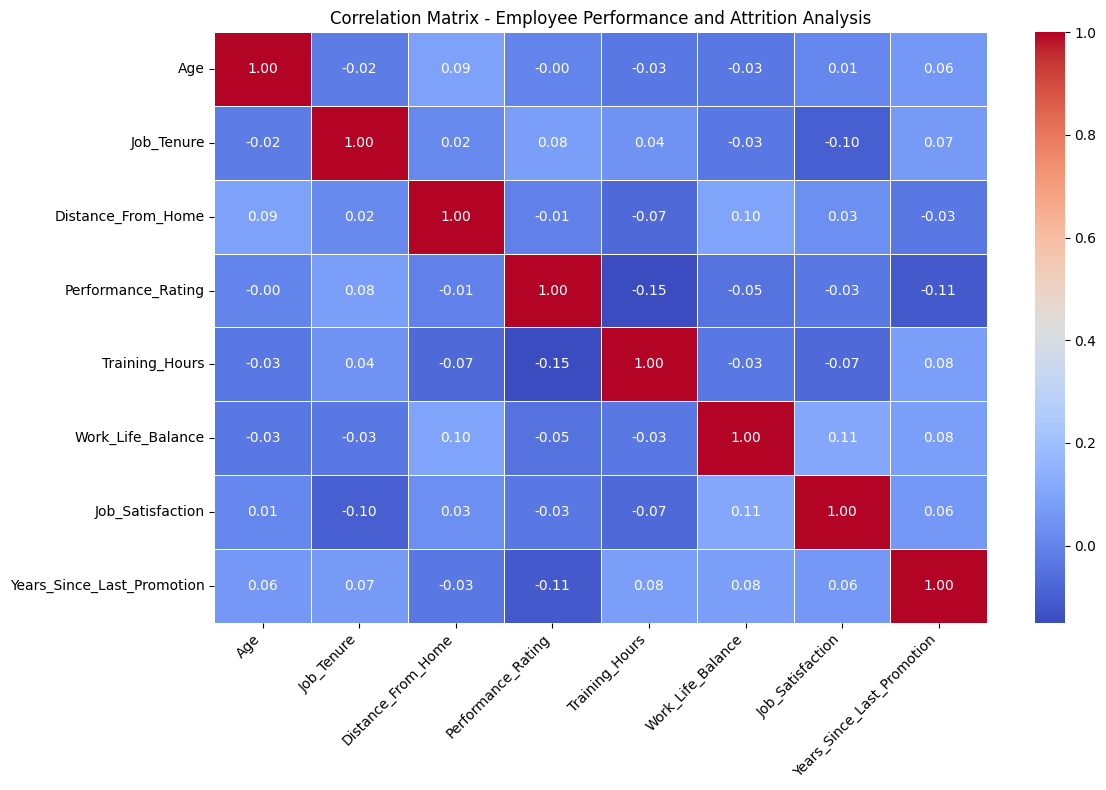

In [ ]:
# ============================================================
# STEP 49: CORRELATION ANALYSIS
# ============================================================

print("=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# Use employees with known attrition status
correlation_df = attrition_analysis_df.copy()

# Select important numerical variables
correlation_columns = [
    "Age",
    "Job_Tenure",
    "Distance_From_Home",
    "Performance_Rating",
    "Training_Hours",
    "Work_Life_Balance",
    "Job_Satisfaction",
    "Years_Since_Last_Promotion"
]

correlation_matrix = correlation_df[correlation_columns].corr().round(2)

print("\nCorrelation Matrix:")

display(correlation_matrix)

# Create a heatmap for easier interpretation
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix - Employee Performance and Attrition Analysis")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

In [ ]:
# ============================================================
# STEP 50: FINAL KPI SUMMARY
# ============================================================

print("=" * 70)
print("FINAL KPI SUMMARY")
print("=" * 70)

# Use employees with known attrition status
kpi_df = attrition_analysis_df.copy()

# ------------------------------------------------------------
# KPI 1: Total Employees with Known Attrition Status
# ------------------------------------------------------------
total_known_employees = len(kpi_df)

# ------------------------------------------------------------
# KPI 2: Attrited Employees
# ------------------------------------------------------------
total_attrited = kpi_df["attrition"].sum()

# ------------------------------------------------------------
# KPI 3: Not Attrited Employees
# ------------------------------------------------------------
total_not_attrited = total_known_employees - total_attrited

# ------------------------------------------------------------
# KPI 4: Attrition Rate
# ------------------------------------------------------------
attrition_rate = (
    total_attrited / total_known_employees * 100
)

# ------------------------------------------------------------
# KPI 5: Retention Rate
# ------------------------------------------------------------
retention_rate = (
    total_not_attrited / total_known_employees * 100
)

# ------------------------------------------------------------
# KPI 6: Average Tenure
# ------------------------------------------------------------
average_tenure = kpi_df["Job_Tenure"].mean()

# ------------------------------------------------------------
# KPI 7: Average Performance Rating
# ------------------------------------------------------------
average_performance = kpi_df["Performance_Rating"].mean()

# ------------------------------------------------------------
# KPI 8: Average Employee Satisfaction
# ------------------------------------------------------------
average_satisfaction = kpi_df["Overall_Satisfaction_Score"].mean()

# ------------------------------------------------------------
# KPI 9: Average Training Hours
# ------------------------------------------------------------
average_training_hours = kpi_df["Training_Hours"].mean()

# ------------------------------------------------------------
# KPI 10: Average Work-Life Balance
# ------------------------------------------------------------
average_work_life_balance = kpi_df["Work_Life_Balance"].mean()

# ------------------------------------------------------------
# KPI 11: Average Job Satisfaction
# ------------------------------------------------------------
average_job_satisfaction = kpi_df["Job_Satisfaction"].mean()

# ------------------------------------------------------------
# Create KPI Summary Table
# ------------------------------------------------------------
kpi_summary = pd.DataFrame({
    "KPI": [
        "Employees with Known Attrition Status",
        "Attrited Employees",
        "Not Attrited Employees",
        "Attrition Rate (%)",
        "Retention Rate (%)",
        "Average Tenure (Years)",
        "Average Performance Rating",
        "Average Employee Satisfaction",
        "Average Training Hours",
        "Average Work-Life Balance",
        "Average Job Satisfaction"
    ],
    "Value": [
        total_known_employees,
        total_attrited,
        total_not_attrited,
        round(attrition_rate, 2),
        round(retention_rate, 2),
        round(average_tenure, 2),
        round(average_performance, 2),
        round(average_satisfaction, 2),
        round(average_training_hours, 2),
        round(average_work_life_balance, 2),
        round(average_job_satisfaction, 2)
    ]
})

print("\nFinal KPI Summary:")

display(kpi_summary)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
print("\nValidation:")
print("Known employees:", total_known_employees)
print("Attrited:", total_attrited)
print("Not Attrited:", total_not_attrited)
print("Attrited + Not Attrited:", total_attrited + total_not_attrited)

print("\n" + "=" * 70)

FINAL KPI SUMMARY

Final KPI Summary:


,KPI,Value
0,Employees with Known Attrition Status,121.00
1,Attrited Employees,58.00
2,Not Attrited Employees,63.00
3,Attrition Rate (%),47.93
4,Retention Rate (%),52.07
5,Average Tenure (Years),9.78
6,Average Performance Rating,2.77
7,Average Employee Satisfaction,2.95
8,Average Training Hours,102.92
9,Average Work-Life Balance,3.04



Validation:
Known employees: 121
Attrited: 58
Not Attrited: 63
Attrited + Not Attrited: 121



In [ ]:
# ============================================================
# STEP 51: FINAL DATASET EXPORT AND VALIDATION
# ============================================================

print("=" * 70)
print("FINAL DATASET EXPORT AND VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Final dataset
# ------------------------------------------------------------
final_df = analysis_df.copy()

# Add Distance Group if not already present
if "Distance_Group" not in final_df.columns:
    final_df["Distance_Group"] = pd.cut(
        final_df["Distance_From_Home"],
        bins=[0, 10, 20, 30, 40, 50],
        labels=["1-10", "11-20", "21-30", "31-40", "41-50"],
        include_lowest=True
    )

# Add Satisfaction Group if not already present
if "Satisfaction_Group" not in final_df.columns:
    final_df["Satisfaction_Group"] = pd.cut(
        final_df["Overall_Satisfaction_Score"],
        bins=[0, 2, 3, 4, 5],
        labels=["Low", "Moderate", "High", "Very High"],
        include_lowest=True
    )

# ------------------------------------------------------------
# Reorder important columns
# ------------------------------------------------------------
final_columns = [
    "Employee_ID",
    "Age",
    "gender",
    "Gender",
    "Department",
    "Job_Role",
    "Education_Level",
    "Marital_Status",
    "Job_Tenure",
    "Tenure_Group",
    "Distance_From_Home",
    "Distance_Group",
    "Performance_Rating",
    "Performance_Category",
    "Last_Promotion_Year",
    "Years_Since_Last_Promotion",
    "Training_Hours",
    "Training_Level",
    "Work_Life_Balance",
    "Job_Satisfaction",
    "Overall_Satisfaction_Score",
    "attrition",
    "Attrition_Status",
    "Attrition_Available",
    "Exit_Interview_Score"
]

final_df = final_df[final_columns]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
print("\nFinal Dataset Shape:")
print(final_df.shape)

print("\nDuplicate Employee IDs:")
print(final_df["Employee_ID"].duplicated().sum())

print("\nMissing Values:")
display(
    final_df.isnull().sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Values"})
)

print("\nAttrition Status Distribution:")
display(
    final_df["Attrition_Status"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={
        "index": "Attrition_Status",
        "Attrition_Status": "Employee_Count"
    })
)

# ------------------------------------------------------------
# Export CSV
# ------------------------------------------------------------
output_file = "Employee_Performance_Attrition_Final.csv"

final_df.to_csv(
    output_file,
    index=False
)

print("\nFinal dataset exported successfully:")
print(output_file)

print("\nFirst 5 rows:")
display(final_df.head())

print("\n" + "=" * 70)
print("COLAB DATA PREPARATION COMPLETED")
print("=" * 70)

FINAL DATASET EXPORT AND VALIDATION

Final Dataset Shape:
(1000, 25)

Duplicate Employee IDs:
0

Missing Values:


,Column,Missing_Values
0,Employee_ID,0
1,Age,0
2,gender,0
3,Gender,0
4,Department,0
5,Job_Role,0
6,Education_Level,0
7,Marital_Status,0
8,Job_Tenure,0
9,Tenure_Group,0



Attrition Status Distribution:


,Employee_Count,count
0,Unknown,879
1,Not Attrited,63
2,Attrited,58



Final dataset exported successfully:
Employee_Performance_Attrition_Final.csv

First 5 rows:


,Employee_ID,Age,gender,Gender,Department,Job_Role,Education_Level,Marital_Status,Job_Tenure,Tenure_Group,...,Years_Since_Last_Promotion,Training_Hours,Training_Level,Work_Life_Balance,Job_Satisfaction,Overall_Satisfaction_Score,attrition,Attrition_Status,Attrition_Available,Exit_Interview_Score
0,1,22,Male,Other,HR,Developer,PhD,Married,1,0-5 Years,...,5,28,Low,3,1,2.0,NaN,Unknown,0,NaN
1,2,38,Male,Other,IT,Marketing Lead,Master's,Married,18,16-20 Years,...,2,174,Very High,3,2,2.5,False,Not Attrited,1,3.0
2,3,35,Genderqueer,Male,Sales,Senior Developer,Bachelor's,Divorced,4,0-5 Years,...,2,119,High,5,4,4.5,NaN,Unknown,0,NaN
3,4,37,Male,Male,Marketing,Senior Developer,Bachelor's,Divorced,5,0-5 Years,...,9,82,Medium,4,1,2.5,NaN,Unknown,0,NaN
4,5,26,Female,Female,Operations,Manager,Master's,Single,10,6-10 Years,...,10,46,Low,2,4,3.0,NaN,Unknown,0,NaN



COLAB DATA PREPARATION COMPLETED


In [ ]:
# SQL Queries Executed Today
"""
Overall KPI Analysis
Department-wise Attrition Analysis
Job Role-wise Attrition Analysis
Performance Rating-wise Attrition Analysis
Work-Life Balance-wise Attrition Analysis
Job Satisfaction-wise Attrition Analysis
Job Tenure Group-wise Attrition Analysis
Age Group-wise Attrition Analysis
Education Level-wise Attrition Analysis
Marital Status-wise Attrition Analysis
Training Level-wise Attrition Analysis
Distance From Home-wise Attrition Analysis
Years Since Last Promotion-wise Attrition Analysis
Overall Satisfaction Group-wise Attrition Analysis
Gender Group-wise Attrition Analysis
Exit Interview Score-wise Attrition Analysis
Performance Category-wise Attrition Analysis
Performance Rating vs Training Hours Analysis
Department × Performance Rating Analysis
Department × Job Satisfaction Analysis
Department × Work-Life Balance Analysis
Department × Training Level Analysis
Department × Age Group Analysis
Department × Tenure Group Analysis
Department-wise Overall KPI Summary
"""

_IncompleteInputError: incomplete input (2485630570.py, line 3)